In [7]:
#libraries and dependencies importation
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import torchvision.transforms as transforms
import torchvision.datasets
from torch.utils.data import Subset
from torch.autograd import Variable
import matplotlib.pyplot as plt
import numpy as np
import torch.nn.functional as F

In [2]:
# helper function of displaying multiple images
def show_images_withPred(images,label,pred,conf) -> None:
    n: int = images.size(0)

    f = plt.figure(figsize=(24, 6))
    for i in range(n):
        # Debug, plot figure
        f.add_subplot(1, n, i + 1)
        plt.imshow(images[i].cpu().squeeze(), cmap='gray')
        plt.title("{} -> {}".format(label[i], pred[i]))
        #plt.title("Conf:{} \n {} -> {}".format(conf[i][pred[i]]*100,label[i], pred[i]))
        plt.axis('off')

    plt.show(block=True)

In [3]:
# Hyperparameters and Data loaders
num_epochs = 10
num_classes = 10
batch_size = 256
learning_rate = 0.001


DATA_PATH = 'data/'
MODEL_STORE_PATH = 'models/'

# transforms to apply to the data
trans = transforms.Compose([transforms.ToTensor()])

# MNIST dataset
train_dataset = torchvision.datasets.MNIST(root=DATA_PATH, train=True, transform=trans, download=True)
test_dataset = torchvision.datasets.MNIST(root=DATA_PATH, train=False, transform=trans)

# Data loader
train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, num_workers=4, shuffle=True)
test_loader = DataLoader(dataset=test_dataset, batch_size=batch_size, num_workers=4, shuffle=False)

100%|██████████| 9.91M/9.91M [00:01<00:00, 5.26MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 124kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.17MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 12.0MB/s]
/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


In [4]:
# neural network
class ConvNet(nn.Module):
    def __init__(self):
        super(ConvNet, self).__init__()

        # convolutional layers(3 layers)
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )

        # 1 fnn with dropout
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.5),
            nn.Linear(3*3*128, 10)
        )

    def forward(self, x):
        out = self.features(x)
        out = self.classifier(out)

        return out


model=ConvNet()
model.cuda()
model.train()

ConvNet(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Dropout(p=0.5, inplace=False)
    (2): Linear(in_features=1152, out_features=10, bias=True)
  )
)

In [5]:
# Loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

In [6]:
#model training
model.train()
loss_list = []
acc_list = []
total_step = len(train_loader)

for epoch in range(num_epochs):
  for i, (images, labels) in enumerate(train_loader):
    images = images.cuda()
    labels = labels.cuda()

    outputs = model(images)

    loss = criterion(outputs, labels)
    loss_list.append(loss.item())

    # Backprop and perform Adam optimization
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # Track the accuracy
    total = labels.size(0)
    _, predicted = torch.max(outputs.data, 1)
    correct = (predicted == labels).sum().item()
    acc_list.append(correct / total)

    if (i%150 == 0):
      print('Epoch [{}/{}], Step [{}/{}], Loss: {:.4f}, Accuracy: {:.2f}%'
              .format(epoch + 1, num_epochs, i, total_step, loss.item(),
                      (correct / total) * 100))

/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Epoch [1/10], Step [0/235], Loss: 2.3094, Accuracy: 10.94%
Epoch [1/10], Step [150/235], Loss: 0.1690, Accuracy: 94.53%
Epoch [2/10], Step [0/235], Loss: 0.1185, Accuracy: 96.48%
Epoch [2/10], Step [150/235], Loss: 0.0767, Accuracy: 98.44%
Epoch [3/10], Step [0/235], Loss: 0.0618, Accuracy: 98.83%
Epoch [3/10], Step [150/235], Loss: 0.0848, Accuracy: 97.66%
Epoch [4/10], Step [0/235], Loss: 0.0767, Accuracy: 95.70%
Epoch [4/10], Step [150/235], Loss: 0.0480, Accuracy: 98.05%
Epoch [5/10], Step [0/235], Loss: 0.0345, Accuracy: 98.44%
Epoch [5/10], Step [150/235], Loss: 0.0337, Accuracy: 98.83%
Epoch [6/10], Step [0/235], Loss: 0.0260, Accuracy: 99.61%
Epoch [6/10], Step [150/235], Loss: 0.0376, Accuracy: 98.83%
Epoch [7/10], Step [0/235], Loss: 0.0149, Accuracy: 99.61%
Epoch [7/10], Step [150/235], Loss: 0.0917, Accuracy: 97.27%
Epoch [8/10], Step [0/235], Loss: 0.0475, Accuracy: 99.22%
Epoch [8/10], Step [150/235], Loss: 0.0172, Accuracy: 99.22%
Epoch [9/10], Step [0/235], Loss: 0.0103

In [8]:
#model evaluation in terms accuracy of predictions
model.eval()
with torch.no_grad():
  correct = 0
  total = 0
  for images, labels in test_loader:
      images = images.cuda()
      labels = labels.cuda()

      outputs = model(images)
      _, predicted = torch.max(outputs.data, 1)
      total += labels.size(0)
      correct += (predicted == labels).sum().item()

print(
  'Accuracy of the model on the 10000 test images: {} %'.format((correct / total) * 100))

Accuracy of the model on the 10000 test images: 99.28 %


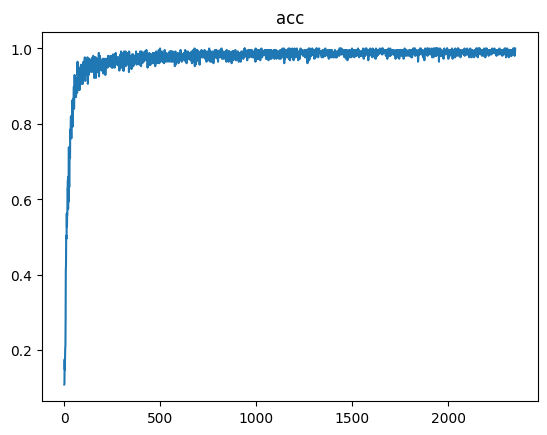

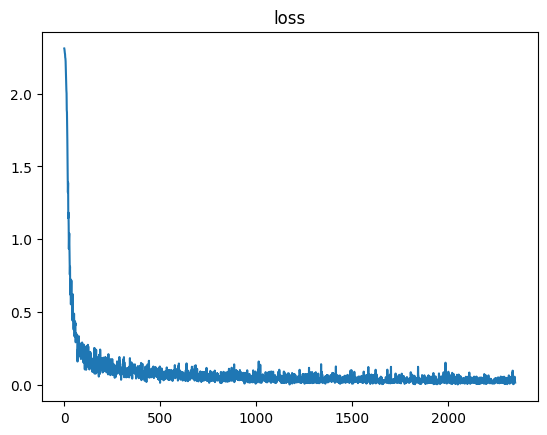

In [9]:
#Visualizations for accurately predicted list data and loss list data
plt.figure()
plt.plot(acc_list)
plt.title('acc')

plt.figure()
plt.plot(loss_list)
plt.title('loss')
plt.show()

Incorrect Predictions:


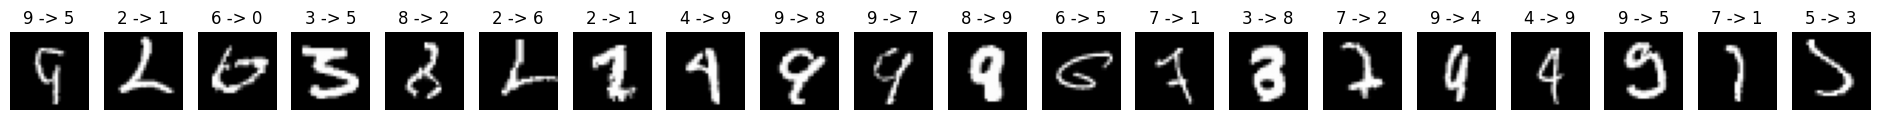

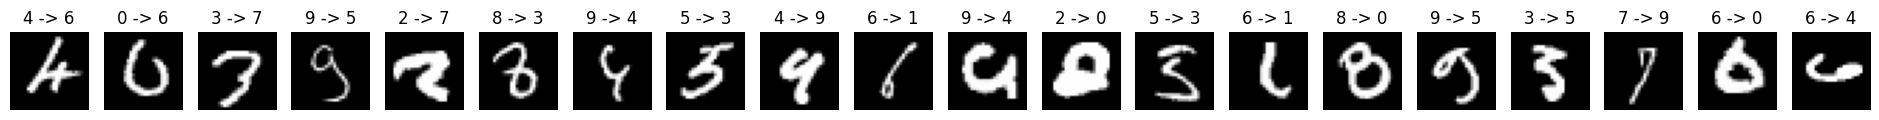

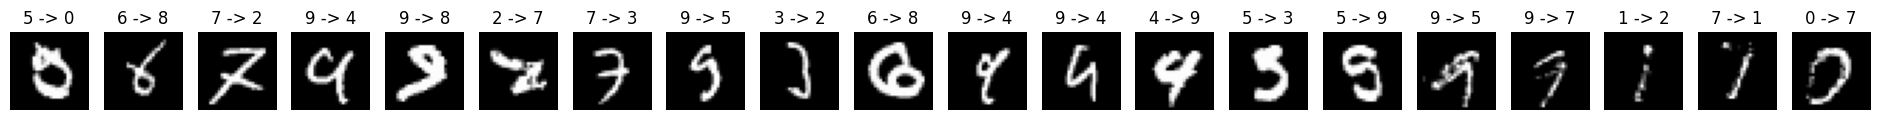

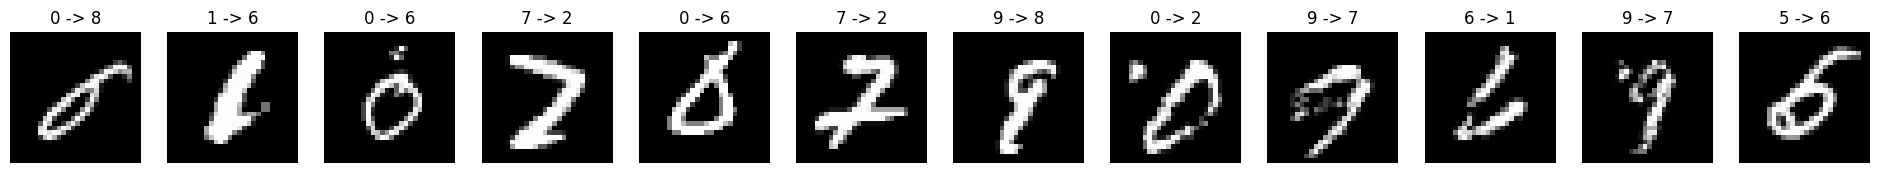


 
 Correct Predictions:


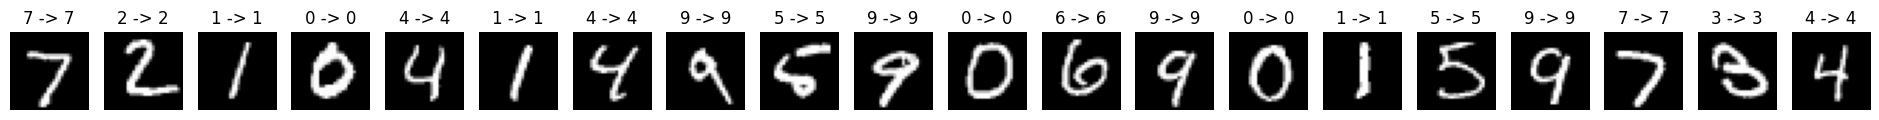

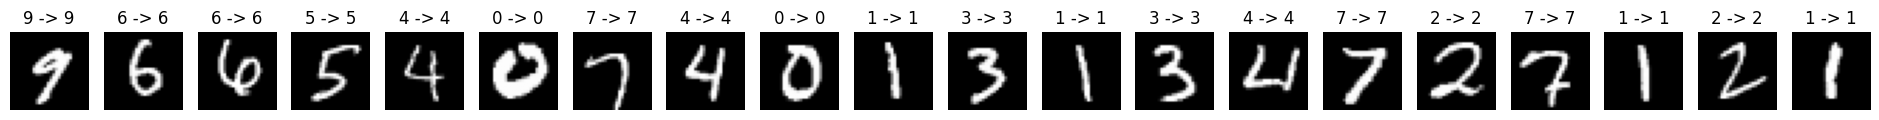

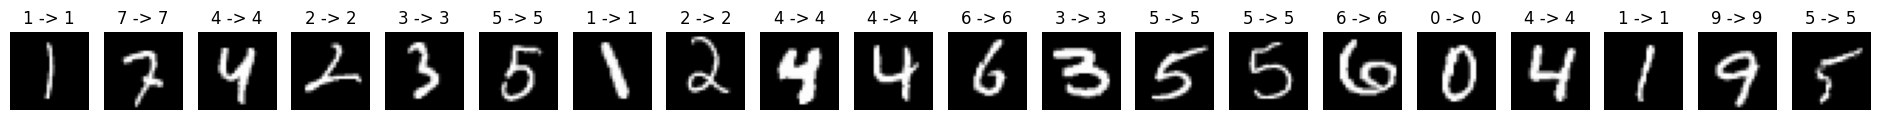

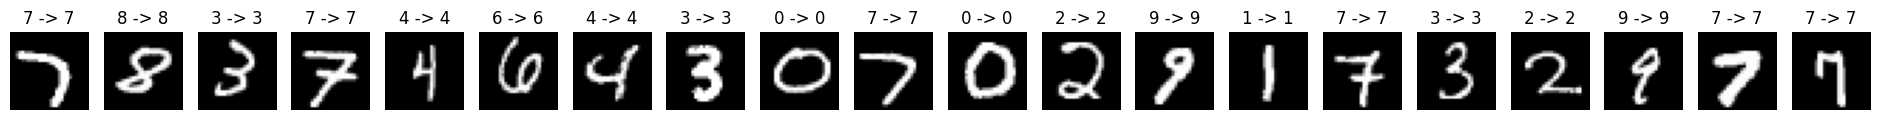

In [10]:
#model evaluation in terms correct predictions vs expected numbers and incorrect predictions vs expected numbers
model.eval()
with torch.no_grad():
  correct = 0
  total = 0
  for i, (images, labels) in enumerate(test_loader):
      images = images.cuda()
      labels = labels.cuda()

      outputs = model(images)
      confidences = outputs.softmax(1)
      _, predicted = torch.max(outputs.data, 1)
      correct_idx = predicted == labels
      incorrect_idx = predicted != labels

      if i == 0:
        correct_images, correct_labels, correct_pred, correct_conf = images[correct_idx], labels[correct_idx], predicted[correct_idx], confidences[correct_idx]
        incorrect_images, incorrect_labels, incorrect_pred, incorrect_conf = images[incorrect_idx], labels[incorrect_idx], predicted[incorrect_idx], confidences[incorrect_idx]
      else:
        correct_images, correct_labels, correct_pred, correct_conf = torch.cat((correct_images, images[correct_idx]),0), torch.cat((correct_labels, labels[correct_idx]),0), torch.cat((correct_pred, predicted[correct_idx]),0), torch.cat((correct_conf, confidences[correct_idx]),0)
        incorrect_images, incorrect_labels, incorrect_pred, incorrect_conf = torch.cat((incorrect_images, images[incorrect_idx]),0), torch.cat((incorrect_labels, labels[incorrect_idx]),0), torch.cat((incorrect_pred, predicted[incorrect_idx]),0), torch.cat((incorrect_conf, confidences[incorrect_idx]),0)

print("Incorrect Predictions:")
plt_num = 20
for i in range(4):
  show_images_withPred(incorrect_images[i*plt_num:(i+1)*plt_num], incorrect_labels[i*plt_num:(i+1)*plt_num],incorrect_pred[i*plt_num:(i+1)*plt_num], correct_conf[i*plt_num:(i+1)*plt_num])

print("\n \n Correct Predictions:")
for i in range(4):
  show_images_withPred(correct_images[i*plt_num:(i+1)*plt_num], correct_labels[i*plt_num:(i+1)*plt_num],correct_pred[i*plt_num:(i+1)*plt_num], incorrect_conf[i*plt_num:(i+1)*plt_num])

del correct_images, correct_labels,correct_pred,correct_conf,incorrect_images,incorrect_labels,incorrect_pred,incorrect_conf

Filter visualization

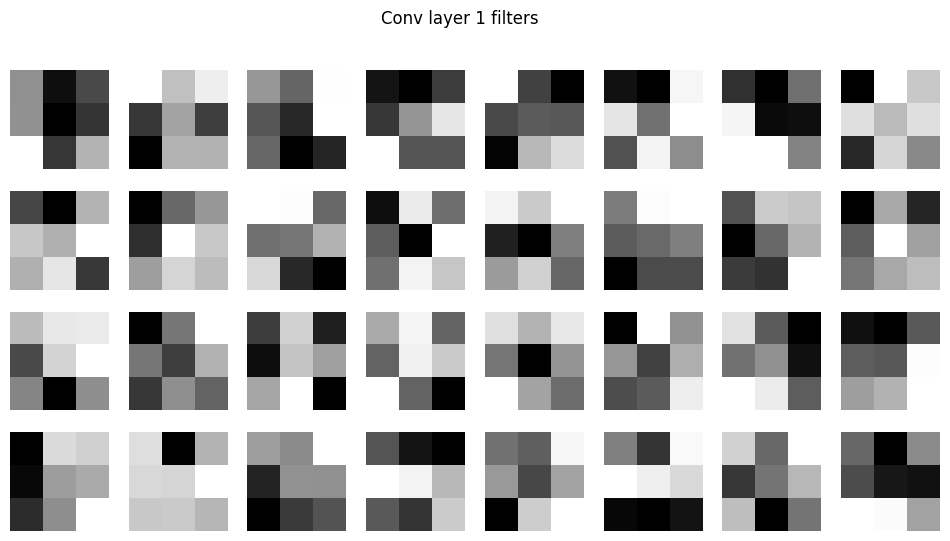

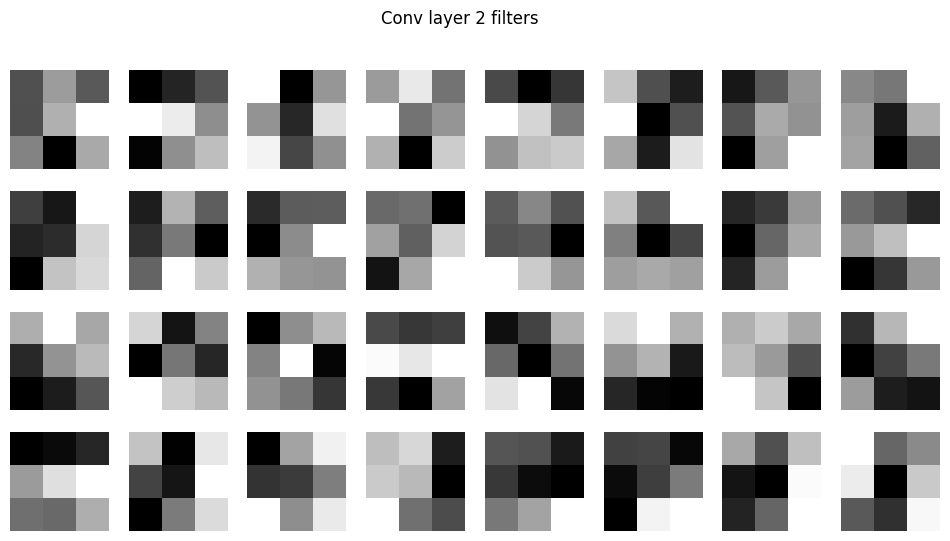

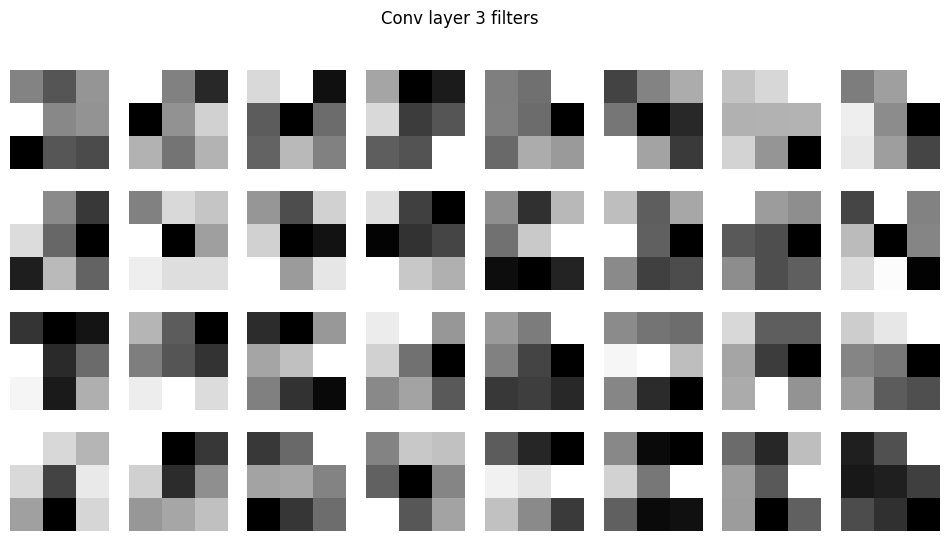

In [11]:
# Conv layer 1: 32 filters, each 3x3
filters = model.features[0].weight.data.cpu()
plt.figure(figsize=(12, 6))
for i in range(32):
    plt.subplot(4, 8, i + 1)
    plt.imshow(filters[i, 0], cmap='gray')
    plt.axis('off')
plt.suptitle('Conv layer 1 filters')
plt.show()

# Conv layer 2: first 32 of 64 filters (averaged over their 32 input channels)
filters = model.features[3].weight.data.cpu()
plt.figure(figsize=(12, 6))
for i in range(32):
    plt.subplot(4, 8, i + 1)
    plt.imshow(filters[i].mean(0), cmap='gray')
    plt.axis('off')
plt.suptitle('Conv layer 2 filters')
plt.show()

# Conv layer 3: first 32 of 128 filters (averaged over their 64 input channels)
filters = model.features[6].weight.data.cpu()
plt.figure(figsize=(12, 6))
for i in range(32):
    plt.subplot(4, 8, i + 1)
    plt.imshow(filters[i].mean(0), cmap='gray')
    plt.axis('off')
plt.suptitle('Conv layer 3 filters')
plt.show()

Feature map visualization

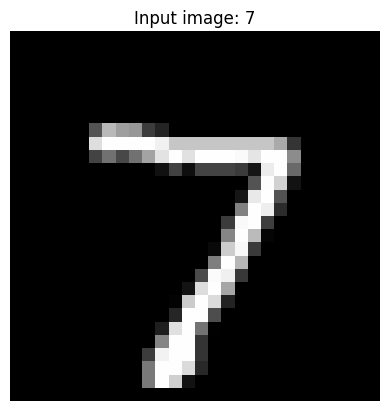

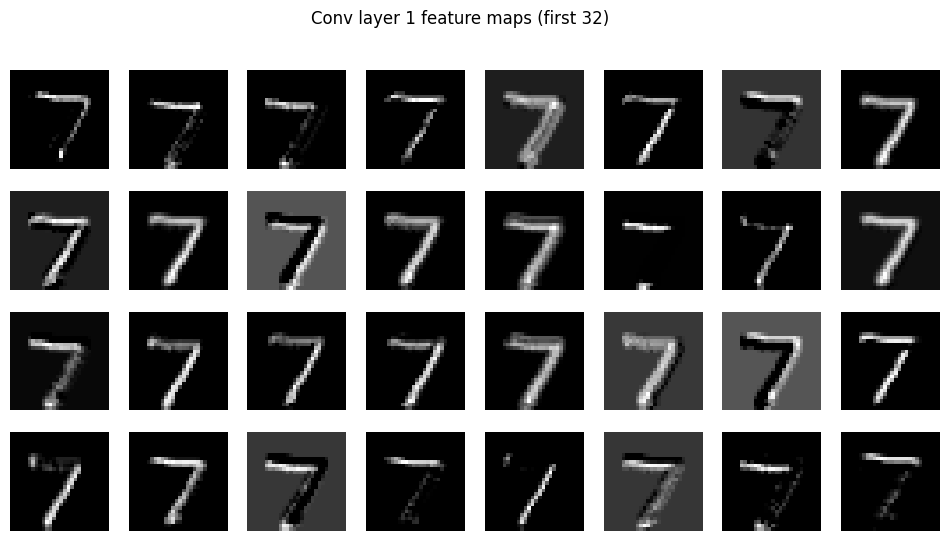

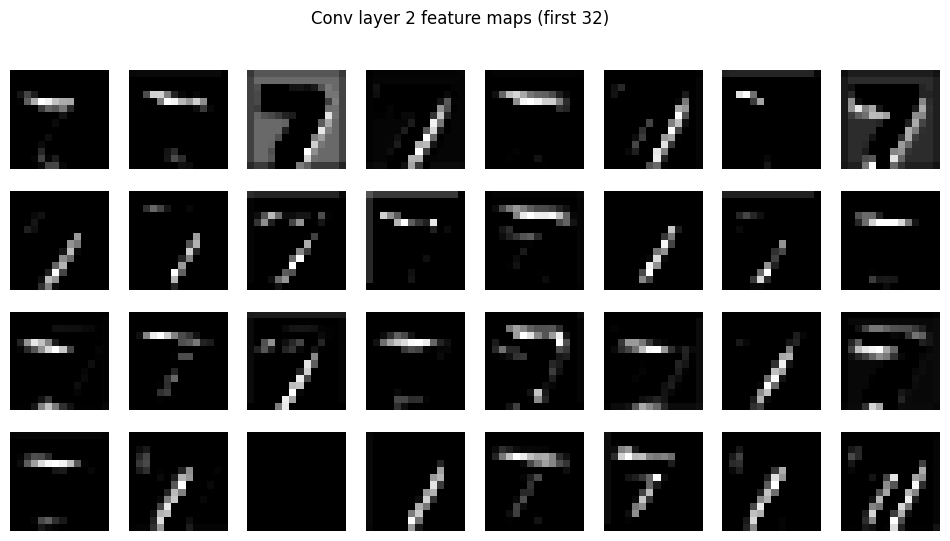

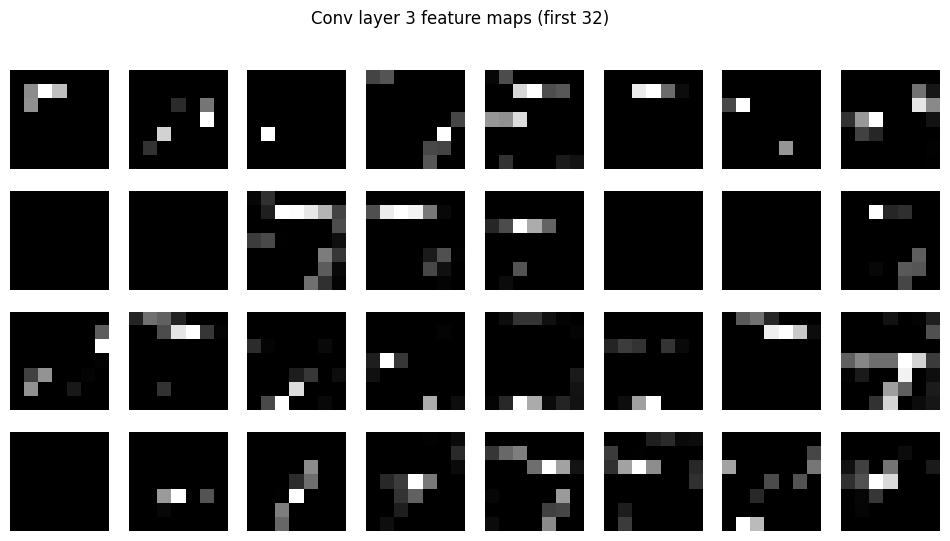

In [12]:
# Take one test image and pass it through the conv layers
image, label = test_dataset[0]
x = image.unsqueeze(0).cuda()

model.eval()
with torch.no_grad():
    maps1 = model.features[:2](x)
    maps2 = model.features[:5](x)
    maps3 = model.features[:8](x)

plt.imshow(image.squeeze(), cmap='gray')
plt.title('Input image: {}'.format(label))
plt.axis('off')
plt.show()

for maps, name in [(maps1, 'Conv layer 1'), (maps2, 'Conv layer 2'), (maps3, 'Conv layer 3')]:
    plt.figure(figsize=(12, 6))
    for i in range(32):
        plt.subplot(4, 8, i + 1)
        plt.imshow(maps[0, i].cpu(), cmap='gray')
        plt.axis('off')
    plt.suptitle(name + ' feature maps (first 32)')
    plt.show()